In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("../data/Sample-Superstore.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/Sample-Superstore.csv'

In [10]:
import os
print(os.listdir("../data"))

['superstore.csv']


In [11]:
df = pd.read_csv("../data/superstore.csv")
df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 2944: invalid start byte

In [12]:
df = pd.read_csv("../data/superstore.csv", encoding='latin1')

In [13]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

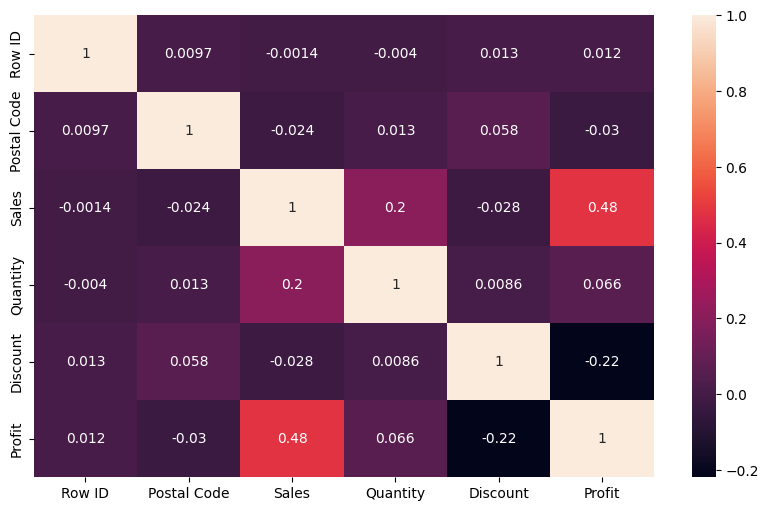

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [18]:
df = df.dropna()

In [19]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df = df.drop_duplicates()

In [22]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [23]:
df['Year'] = df['Order Date'].dt.year

In [24]:
df.describe()

,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit,Year
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555


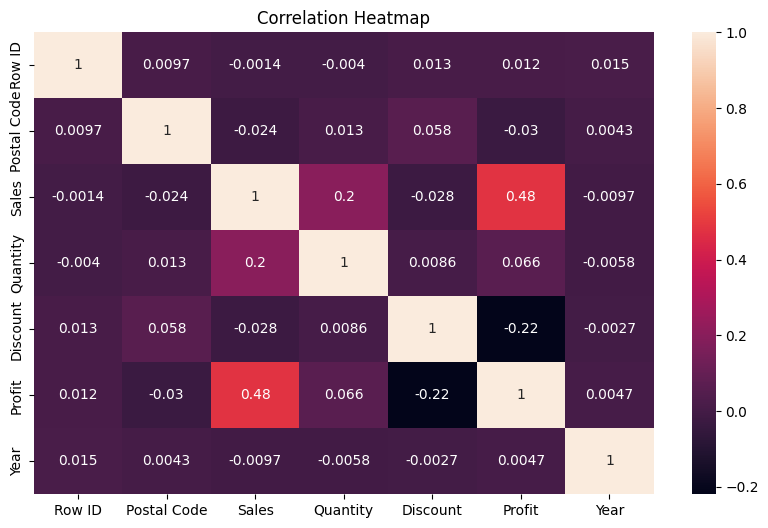

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

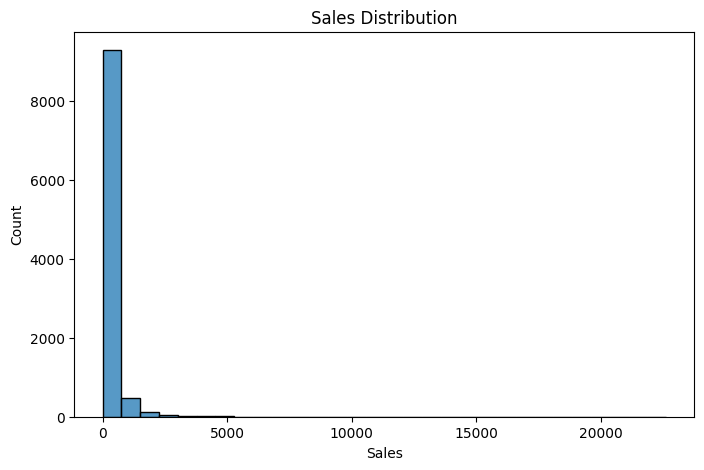

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

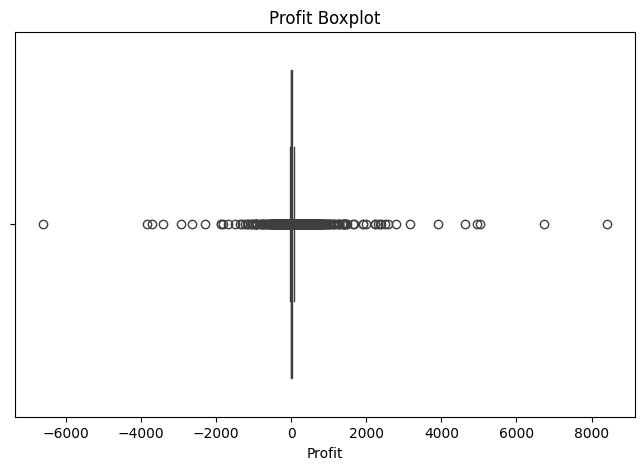

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Profit'])
plt.title("Profit Boxplot")
plt.show()

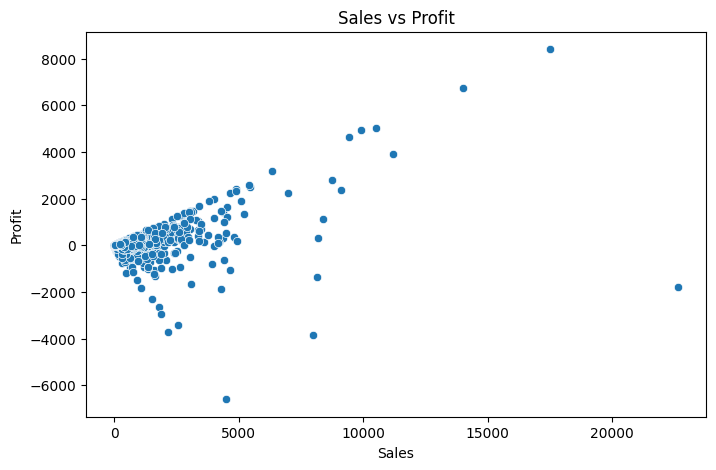

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Sales'], y=df['Profit'])
plt.title("Sales vs Profit")
plt.show()

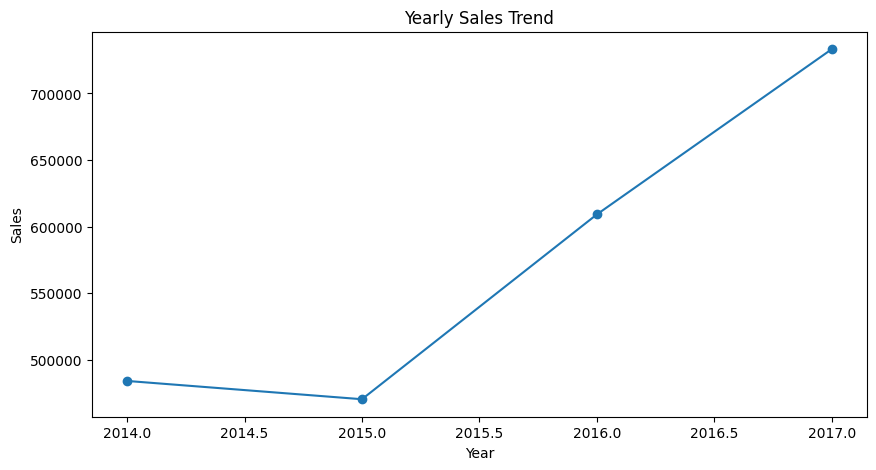

In [29]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot(kind='line', marker='o')

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

In [30]:
X = df[['Sales', 'Quantity', 'Discount']]
y = df['Profit']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 69.77214730362897
MSE: 83592.67395643325
RMSE: 289.123976792713
R2 Score: -0.7240890405096128


In [34]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [35]:
print("Decision Tree R2 Score:", r2_score(y_test, dt_pred))

Decision Tree R2 Score: -0.6176110878310956


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [37]:
print("Random Forest R2 Score:", r2_score(y_test, rf_pred))

Random Forest R2 Score: -0.2849593759742888


In [38]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']

scores = [
    r2_score(y_test, y_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred)
]

comparison = pd.DataFrame({
    'Model': models,
    'R2 Score': scores
})

comparison

,Model,R2 Score
0,Linear Regression,-0.724089
1,Decision Tree,-0.617611
2,Random Forest,-0.284959


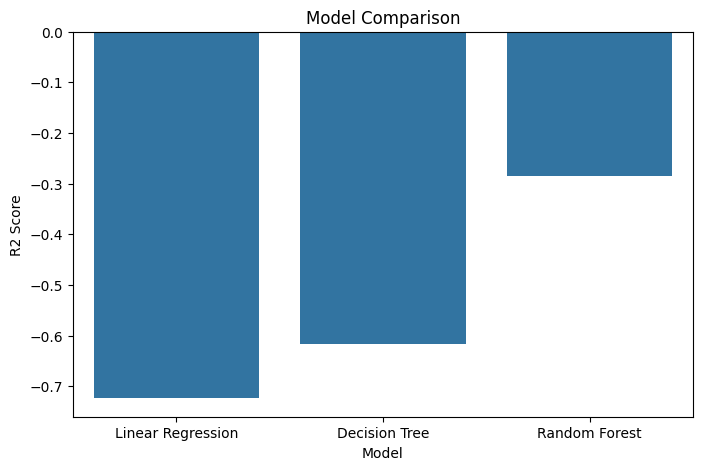

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='R2 Score', data=comparison)

plt.title("Model Comparison")

plt.show()